# **Análisis Exploratorio de Datos - Procesamiento de Lenguaje Natural**

## **1. Librerias**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk

from tqdm import trange
from nltk import tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from nltk.util import ngrams

In [2]:
import warnings
warnings.filterwarnings('ignore')
nltk.download('omw-1.4', quiet=True)
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (17,7)
plt.rcParams['font.size'] = 18

## **2. Cargando Datos**

In [3]:
df = pd.read_csv('../Data/Resume/Resume.csv')
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


### **2.1. Número de Caracteres por Resumen**

In [4]:
length = len(df['Resume_str'][0])
print(f"El número de caracteres del primer resumen es: {length}")   

El número de caracteres del primer resumen es: 5442


In [5]:
df['Length'] = df['Resume_str'].str.len()

In [6]:
df[['Resume_str', 'Length']].head()

,Resume_str,Length
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,5442
1,"HR SPECIALIST, US HR OPERATIONS ...",5572
2,HR DIRECTOR Summary Over 2...,7720
3,HR SPECIALIST Summary Dedica...,2855
4,HR MANAGER Skill Highlights ...,9172


### **2.2. Número de Palabras por Resumen**

In [7]:
word_count = df['Resume_str'][0].split()
print(f'numero de palabras en el primer resumen: {len(word_count)}')

numero de palabras en el primer resumen: 674


In [8]:
def word_count(text):
    text_list = text.split()
    return len(text_list)

# Crear columna
df['Word_count'] = df['Resume_str'].apply(word_count)

# Ver resultados
df[['Resume_str', 'Word_count']].head()

,Resume_str,Word_count
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,674
1,"HR SPECIALIST, US HR OPERATIONS ...",708
2,HR DIRECTOR Summary Over 2...,1017
3,HR SPECIALIST Summary Dedica...,379
4,HR MANAGER Skill Highlights ...,1206


### **2.3. Longitud Promedio de Palabras**

In [9]:
df['mean_word_length'] = df['Resume_str'].map(
    lambda text: np.mean([len(word) for word in text.split()])
)

# Ver resultados
df[['mean_word_length']].head()

,mean_word_length
0,6.459941
1,6.307910
2,6.218289
3,5.997361
4,6.368159


### **2.4. Longitud promedio de oraciones**

In [10]:
sample_sent_length = np.mean(
    [len(sent) for sent in sent_tokenize(df['Resume_str'][0])]
)

print(f'longitud promedio de oraciones: {sample_sent_length}')


# Crear columna
df['mean_sent_length'] = df['Resume_str'].map(
    lambda text: np.mean([len(sent) for sent in sent_tokenize(text)])
)

# Ver resultados
df[['mean_sent_length']].head()

longitud promedio de oraciones: 205.53846153846155


,mean_sent_length
0,205.538462
1,202.074074
2,199.921053
3,164.823529
4,164.236364


## **3. Resumen Estadistico**

In [11]:
eda_cols = [
    'Length',
    'Word_count',
    'mean_word_length',
    'mean_sent_length'
]

df[eda_cols].describe()

,Length,Word_count,mean_word_length,mean_sent_length
count,2484.000000,2484.000000,2483.000000,2483.000000
mean,6295.308776,811.325684,6.306148,250.672636
std,2769.251458,371.006906,0.370578,334.212249
min,21.000000,0.000000,4.559471,63.300000
25%,5160.000000,651.000000,6.107087,131.621125
50%,5886.500000,757.000000,6.332180,166.100000
75%,7227.250000,933.000000,6.549290,232.016830
max,38842.000000,5190.000000,7.551282,7170.000000


El análisis descriptivo de las métricas textuales muestra que los resumes del dataset presentan una alta variabilidad en tamaño y estructura. En promedio, cada documento contiene aproximadamente 6,295 caracteres y 811 palabras.La desviación estándar elevada tanto en longitud como en número de palabras evidencia una importante heterogeneidad entre los documentos analizados.

La longitud promedio de las palabras fue de 6.3 caracteres, sugiriendo el uso frecuente de vocabulario técnico y términos profesionales relativamente extensos. Asimismo, la longitud promedio de las oraciones fue de aproximadamente 250 caracteres, lo que refleja la presencia de descripciones amplias sobre experiencia laboral, habilidades y formación académica.

Se identificaron resumes muy cortos, con apenas 21 caracteres y 0 palabras útiles, así como documentos extremadamente extensos, alcanzando hasta 38,842 caracteres y más de 5,000 palabras. Esto sugiere la existencia de posibles outliers o inconsistencias en algunos registros.

En términos de distribución, el 50% de los resumes contiene menos de 757 palabras y menos de 5,886 caracteres, mientras que el 75% no supera las 933 palabras. Estos resultados indican que la mayoría de los documentos mantiene una longitud relativamente moderada, aunque existe un subconjunto de resumes considerablemente más extensos que incrementa el promedio general del dataset.

## **4. Análisis de Clases**

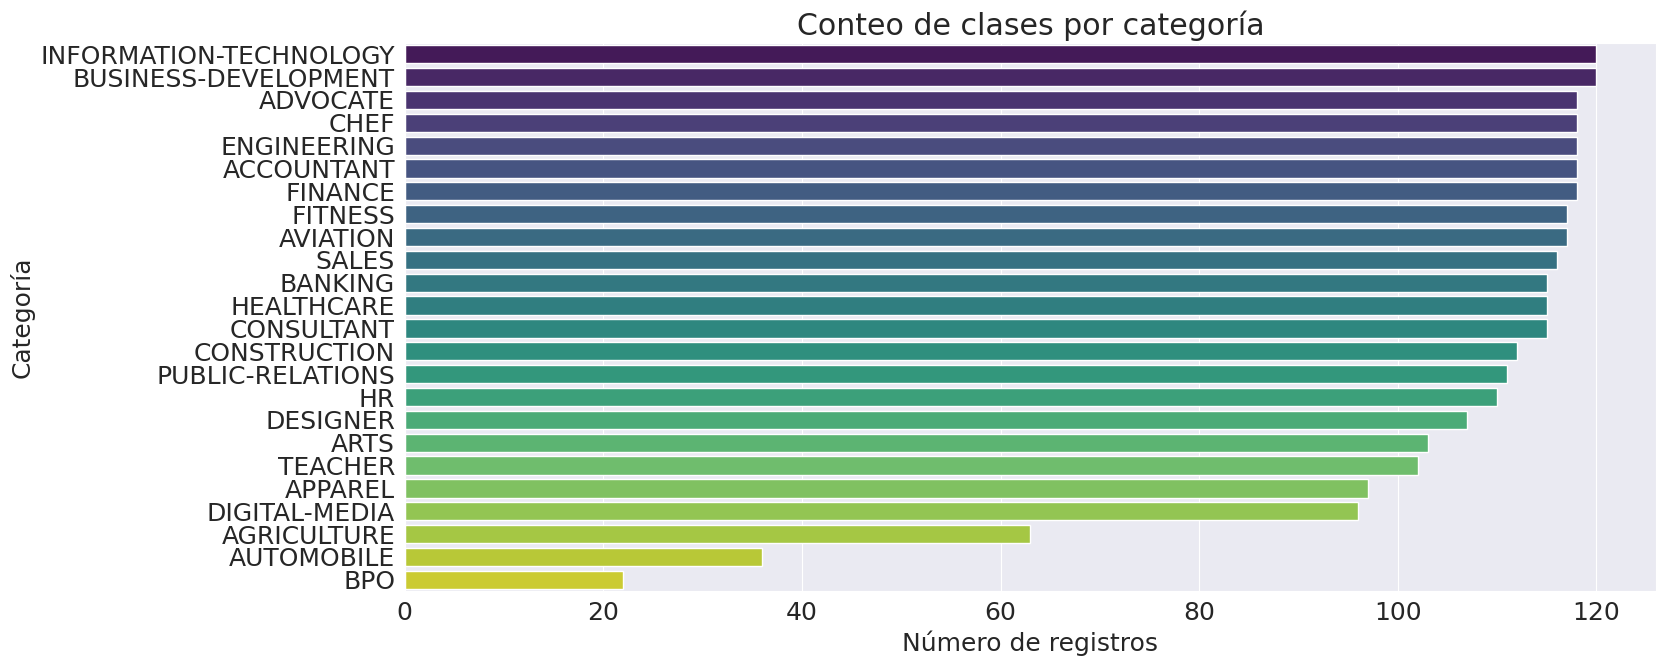

In [12]:
conteo = df["Category"].value_counts()
sns.barplot(y=conteo.index, x=conteo.values, palette="viridis")
plt.title("Conteo de clases por categoría")
plt.xlabel("Número de registros")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()


En general, se observa una distribución relativamente equilibrada entre la mayoría de las categorías, ya que gran parte de ellas presenta entre 90 y 120 registros aproximadamente.

Las categorías con mayor número de registros son `INFORMATION-TECHNOLOGY`, `BUSINESS-DEVELOPMENT` y `ADVOCATE`, lo que indica una mayor representación de perfiles tecnológicos, administrativos y legales dentro del conjunto de datos. Asimismo, áreas como `ENGINEERING`, `FINANCE`, `ACCOUNTANT` y `HEALTHCARE` también poseen una participación considerable, reflejando diversidad ocupacional en el dataset.

Por otro lado, algunas categorías presentan una representación significativamente menor, especialmente `BPO` y `AUTOMOBILE`, que contienen muchos menos registros en comparación con las demás clases. Esto evidencia un desbalance parcial en el dataset, el cual podría influir en el modelado.

En términos generales, el dataset presenta una distribución multicategoría relativamente amplia y diversa, aunque con ciertas diferencias en la cantidad de muestras por clase que deben considerarse durante el análisis y entrenamiento de modelos NLP.


## **5. Longitud de textos**

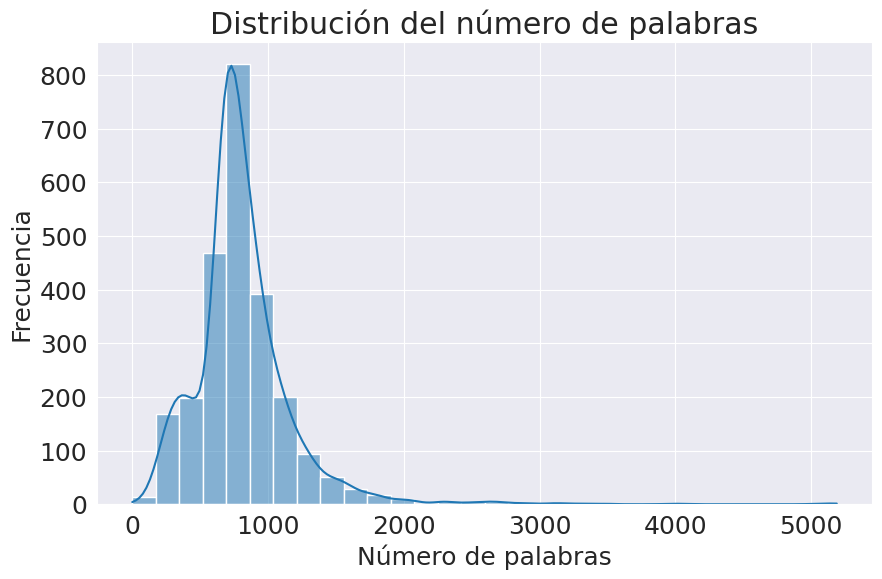

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Word_count'],
    bins=30,
    kde=True
)

plt.title('Distribución del número de palabras')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')

plt.show()

El histograma muestra la distribución del número de palabras presentes en los resumes del dataset. Se observa que la mayor concentración de documentos se encuentra aproximadamente entre 500 y 1,000 palabras, con un pico cercano a las 700–800 palabras, lo que indica que la mayoría de los resumes tiene una longitud moderada y relativamente homogénea.

La distribución presenta una clara asimetría positiva (sesgo hacia la derecha), ya que existe una cola larga que se extiende hasta valores superiores a 5,000 palabras. Esto evidencia la presencia de algunos resumes extremadamente extensos en comparación con la mayoría de los documentos.

Además, la disminución progresiva de la frecuencia a medida que aumenta el número de palabras indica que los resumes muy largos son poco comunes dentro del dataset. En términos generales, el gráfico sugiere que la distribución no es normal y que existen valores atípicos que incrementan considerablemente la dispersión de los datos.

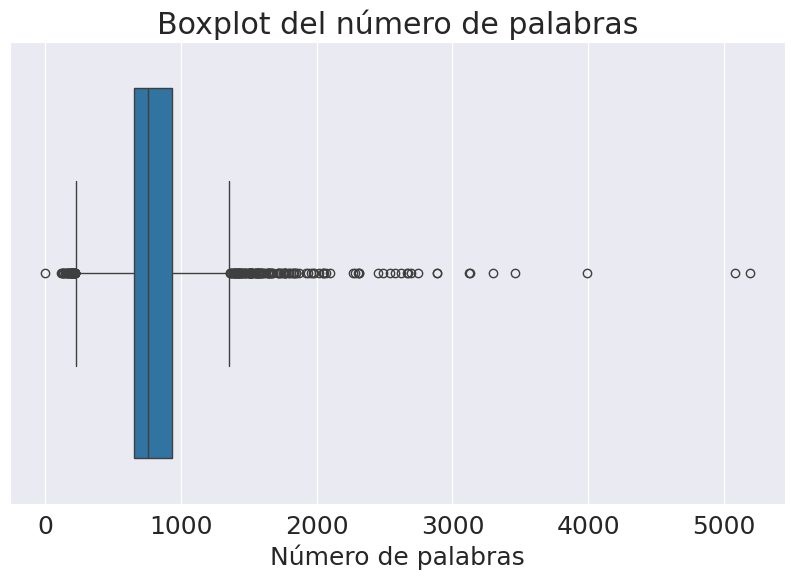

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Word_count']
)

plt.title('Boxplot del número de palabras')
plt.xlabel('Número de palabras')

plt.show()

El boxplot permite analizar la dispersión y la presencia de valores atípicos en el número de palabras de los resumes. La caja central concentra el 50% de los documentos, mostrando que la mayoría de los resumes se encuentra en un rango relativamente estable alrededor de las 600 a 1,000 palabras aproximadamente.

La línea de la mediana se ubica cerca del centro de la caja, indicando que gran parte de los documentos tiene una longitud similar. Sin embargo, se observa una gran cantidad de puntos fuera de los límites superiores del boxplot, lo que confirma la existencia de numerosos outliers correspondientes a resumes extremadamente extensos.

Asimismo, la longitud de los bigotes y la alta concentración de outliers hacia valores altos evidencian una distribución sesgada positivamente. Esto sugiere que, aunque la mayoría de los resumes mantiene una longitud moderada, existe un subconjunto reducido de documentos mucho más largos que afecta significativamente la variabilidad general del dataset.


## **6. Frecuencia de Palabras**

In [15]:
text = " ".join(df['Resume_str'].astype(str))

# minúsculas
text = text.lower()

# reemplazar caracteres especiales por espacio
text = re.sub(r'[^a-zA-Z]', ' ', text)

# eliminar espacios múltiples
text = re.sub(r'\s+', ' ', text)

words = text.split()


In [16]:

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Eliminar stopwords
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

filtered_words[:20]

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/guirlessa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['administrator',
 'marketing',
 'associate',
 'administrator',
 'summary',
 'dedicated',
 'customer',
 'service',
 'manager',
 'years',
 'experience',
 'hospitality',
 'customer',
 'service',
 'management',
 'respected',
 'builder',
 'leader',
 'customer',
 'focused']

La eliminación de stopwords permitió depurar el texto y conservar únicamente las palabras con mayor contenido semántico dentro de los resumes. Como resultado, desaparecieron términos comunes del idioma inglés que no aportan significado relevante al análisis, tales como artículos, preposiciones y conectores.

In [17]:
word_freq = Counter(filtered_words)

top_words = word_freq.most_common(20)

# Convertir a DataFrame
top_words_df = pd.DataFrame(
    top_words,
    columns=['Word', 'Frequency']
)

top_words_df

,Word,Frequency
0,state,16159
1,company,15212
2,city,15077
3,management,12174
4,name,11739
5,sales,8275
6,customer,7927
7,business,7866
8,skills,7729
9,new,6409


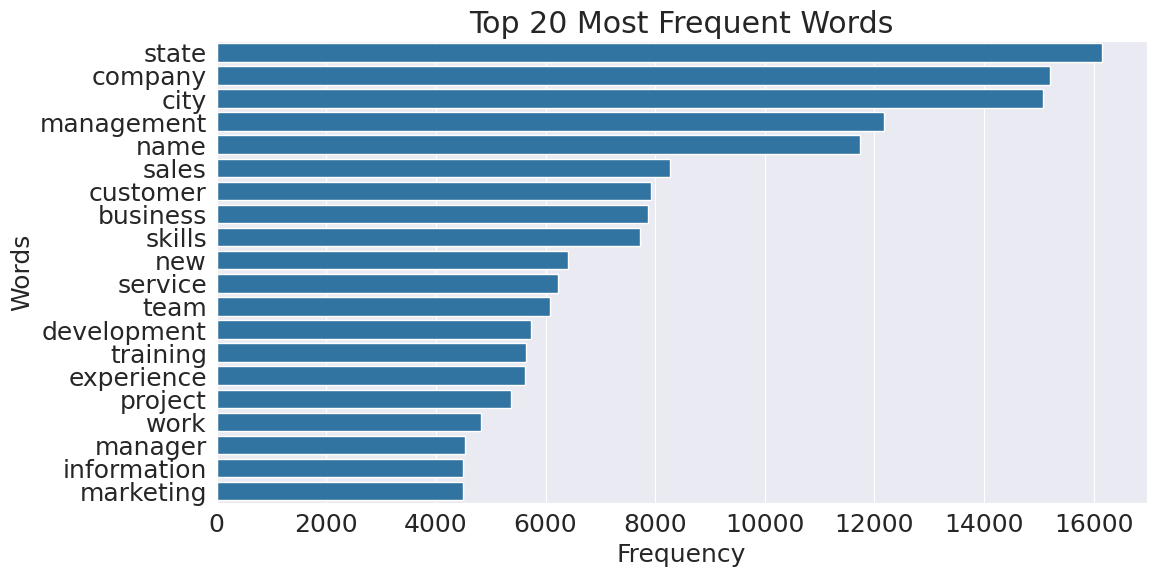

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_words_df,
    x='Frequency',
    y='Word'
)

plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Words')

plt.show()

El análisis de frecuencia de palabras permitió identificar los términos más utilizados dentro de los resumes del dataset. Las palabras más frecuentes fueron `state`, `company`, `city` y `name`, lo que evidencia la fuerte presencia de información estructural y datos organizacionales propios de las plantillas de hojas de vida.

Asimismo, se destacan términos relacionados con el ámbito empresarial y profesional, como `management`, `sales`, `business`, `project`, `marketing` y `manager`, indicando una alta representación de perfiles administrativos, comerciales y de gestión. También aparecen palabras asociadas a habilidades y competencias laborales, entre ellas `skills`, `team`, `training`, `experience` y `service`, lo que refleja la importancia de las habilidades técnicas y blandas en la construcción de los resumes.

Por otro lado, términos como `customer` y `development` sugieren una fuerte orientación hacia áreas de atención al cliente, desarrollo organizacional y crecimiento empresarial. En conjunto, estos resultados muestran que el dataset contiene un lenguaje predominantemente corporativo y profesional, caracterizado por referencias frecuentes a gestión, trabajo en equipo, experiencia laboral y habilidades organizacionales.


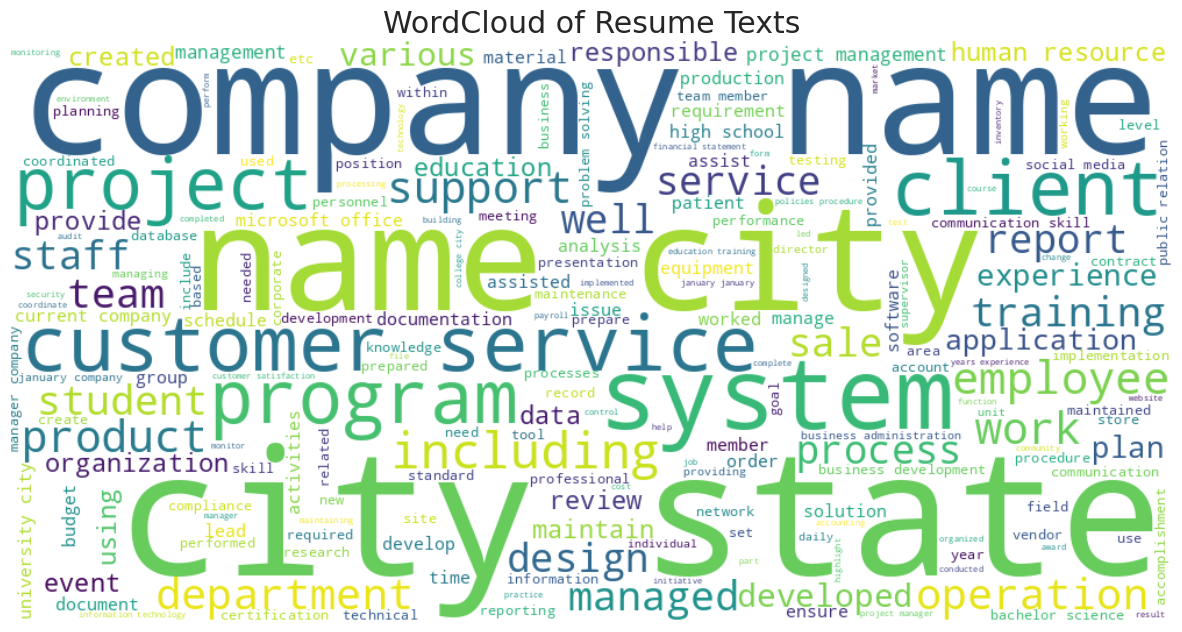

In [19]:
# Crear WordCloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(" ".join(filtered_words))

# Visualizar
plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('WordCloud of Resume Texts')

plt.show()

La WordCloud permite visualizar de manera general las palabras más representativas y frecuentes dentro de los resumes analizados. El tamaño de cada término refleja su nivel de frecuencia en el dataset, por lo que las palabras más grandes corresponden a los conceptos más recurrentes en los documentos.

Se observa una alta predominancia de términos como `company`, `name`, `state`, `system`, `customer`, `service`, `project` y `client`, lo que evidencia que gran parte del contenido está relacionado con contextos empresariales, gestión organizacional y atención al cliente. Asimismo, palabras como `management`, `training`, `support`, `operation` y `program` sugieren una fuerte orientación hacia perfiles administrativos, operativos y de coordinación de procesos.

También destacan términos vinculados a experiencia laboral y competencias profesionales, tales como `development`, `team`, `process`, `product`, `report` y `application`, indicando la presencia de habilidades relacionadas con gestión de proyectos, trabajo colaborativo y uso de herramientas tecnológicas.

Por otro lado, la aparición de palabras estructurales como `company`, `name`, `state` y `department` confirma que parte importante del texto corresponde a información típica de las plantillas de hojas de vida y datos organizacionales.

En conjunto, la WordCloud evidencia que el dataset posee un lenguaje predominantemente corporativo y profesional, enfocado en experiencia laboral, gestión empresarial, atención al cliente, procesos organizacionales y habilidades técnicas.


## **7. N-Gramas**

### **7.1. Bigramas**

In [20]:
# Crear bigramas
bigrams = list(ngrams(filtered_words, 2))

# Contar frecuencia
bigram_freq = Counter(bigrams)

# Top 20
top_bigrams = bigram_freq.most_common(20)

# Ver resultados
top_bigrams[:10]

[(('city', 'state'), 14107),
 (('company', 'name'), 11563),
 (('name', 'city'), 9900),
 (('customer', 'service'), 3061),
 (('project', 'management'), 1198),
 (('current', 'company'), 1177),
 (('microsoft', 'office'), 1147),
 (('university', 'city'), 1107),
 (('high', 'school'), 1069),
 (('business', 'development'), 914)]

In [21]:
bigram_df = pd.DataFrame(
    [
        (' '.join(bigram), freq)
        for bigram, freq in top_bigrams
    ],
    columns=['Bigram', 'Frequency']
)

bigram_df

,Bigram,Frequency
0,city state,14107
1,company name,11563
2,name city,9900
3,customer service,3061
4,project management,1198
5,current company,1177
6,microsoft office,1147
7,university city,1107
8,high school,1069
9,business development,914


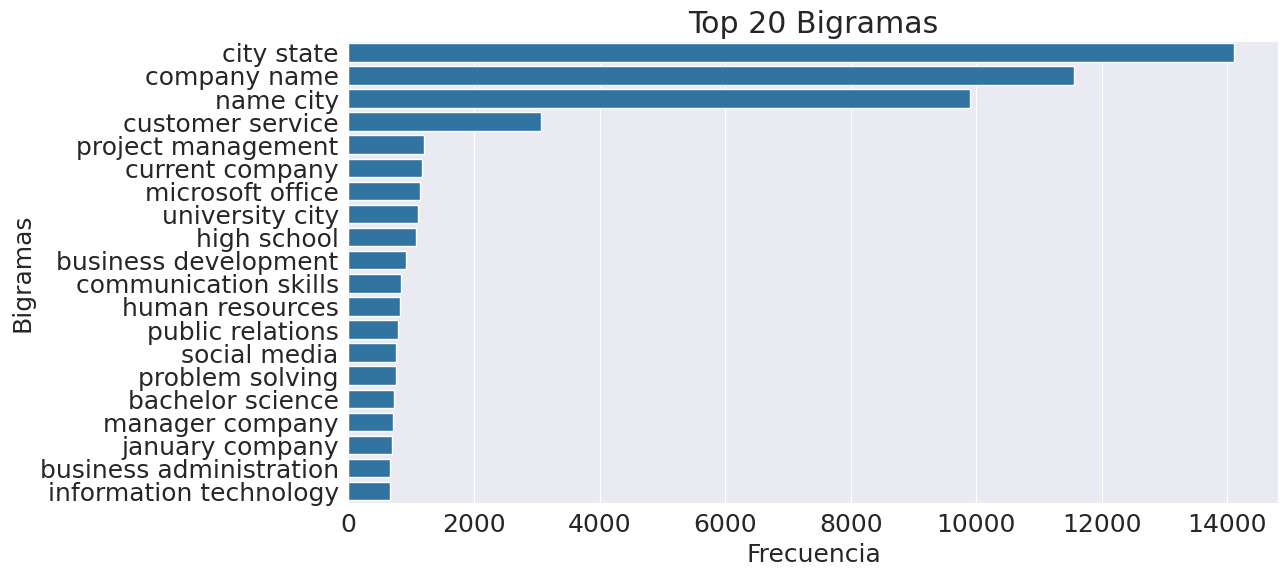

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bigram_df,
    x='Frequency',
    y='Bigram'
)

plt.title('Top 20 Bigramas')
plt.xlabel('Frecuencia')
plt.ylabel('Bigramas')

plt.show()

El análisis de bigramas permitió identificar las combinaciones de palabras más frecuentes dentro de los resumes. Los resultados muestran que gran parte del texto está compuesto por estructuras típicas de hojas de vida, como `city state` y `company name`, asociadas a información personal y organizacional. Asimismo, se identificaron términos relevantes relacionados con habilidades y perfiles profesionales, entre ellos `customer service`, `project management`, `business development` e `information technology`, lo que evidencia una alta presencia de competencias administrativas, tecnológicas y de atención al cliente. También destacan expresiones vinculadas a habilidades blandas, como `communication skills` y `problem solving`, así como términos asociados a formación académica, por ejemplo `high school` y `business administration`. En conjunto, los bigramas permitieron capturar contexto semántico relevante y comprender mejor los patrones lingüísticos predominantes en el dataset.

### **7.2. Trigramas**

In [23]:
# Crear trigramas
trigrams = list(ngrams(filtered_words, 3))

# Frecuencia
trigram_freq = Counter(trigrams)

# Top 20
top_trigrams = trigram_freq.most_common(20)
top_trigrams[:10]

[(('company', 'name', 'city'), 9900),
 (('name', 'city', 'state'), 9719),
 (('current', 'company', 'name'), 1173),
 (('university', 'city', 'state'), 1030),
 (('manager', 'company', 'name'), 704),
 (('january', 'company', 'name'), 688),
 (('college', 'city', 'state'), 615),
 (('city', 'state', 'usa'), 535),
 (('january', 'january', 'company'), 490),
 (('city', 'state', 'responsible'), 454)]

In [24]:
trigram_df = pd.DataFrame(
    [
        (' '.join(trigram), freq)
        for trigram, freq in top_trigrams
    ],
    columns=['Trigram', 'Frequency']
)

trigram_df

,Trigram,Frequency
0,company name city,9900
1,name city state,9719
2,current company name,1173
3,university city state,1030
4,manager company name,704
5,january company name,688
6,college city state,615
7,city state usa,535
8,january january company,490
9,city state responsible,454


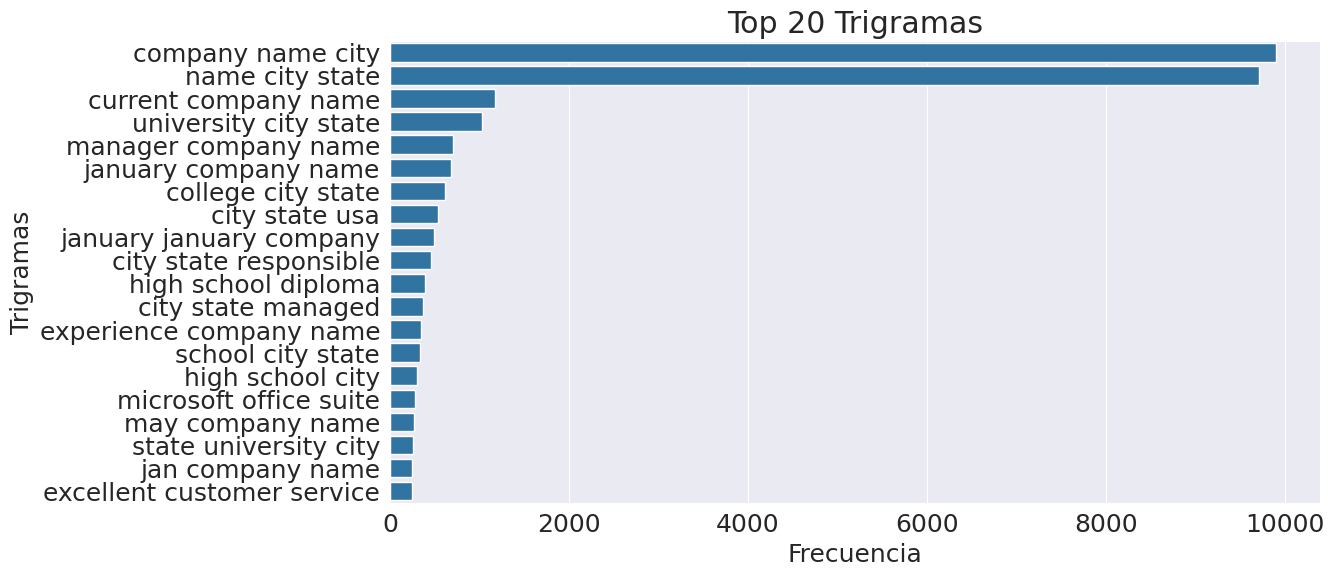

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=trigram_df,
    x='Frequency',
    y='Trigram'
)

plt.title('Top 20 Trigramas')
plt.xlabel('Frecuencia')
plt.ylabel('Trigramas')

plt.show()

El análisis de trigramas permitió identificar secuencias de tres palabras frecuentes dentro de los resumes, evidenciando patrones estructurales y temáticos del dataset. Los trigramas más repetidos, como `company name city` y `name city state`, corresponden principalmente a formatos típicos de hojas de vida relacionados con información de ubicación y referencias organizacionales, lo que indica una alta presencia de estructuras repetitivas propias de plantillas de CVs. Asimismo, se encontraron expresiones asociadas a formación académica y experiencia profesional, como `high school diploma`, `university city state` y `experience company name`. También destacan trigramas relacionados con competencias laborales y herramientas profesionales, por ejemplo `microsoft office suite` y `excellent customer service`, evidenciando habilidades técnicas y de atención al cliente frecuentemente mencionadas en los perfiles analizados. En conjunto, los trigramas permiten capturar un contexto semántico más específico que los bigramas, proporcionando una mejor comprensión de los patrones lingüísticos y profesionales presentes en el dataset.

## **8. Interpretación**

### **¿Las Clases estan desbalanceadas?**

El dataset presenta un balance moderado entre las diferentes categorías profesionales. Aunque la mayoría de las clases contiene una cantidad similar de resumes, existen algunas categorías con mayor representación, como `INFORMATION-TECHNOLOGY`, `BUSINESS-DEVELOPMENT` y `ADVOCATE`, mientras que otras poseen menos registros, por ejemplo `BPO` y `AUTOMOBILE`. Esto indica que no existe un desbalance extremo, pero sí diferencias que podrían influir en el desempeño de modelos de clasificación, especialmente en las categorías con menor cantidad de ejemplos.

### **¿Los textos son cortos o largos?**

Los resumes del dataset pueden considerarse relativamente largos. En promedio, cada documento contiene aproximadamente 811 palabras y más de 6,000 caracteres, lo que evidencia un alto nivel de detalle en la descripción de experiencia laboral, habilidades y formación académica. Además, la distribución del número de palabras muestra que la mayoría de los textos se concentra entre 500 y 1,000 palabras. Sin embargo, también existen resumes extremadamente extensos que superan las 5,000 palabras, generando una distribución sesgada hacia valores altos.

### **¿Hay ruido en los datos?**

Sí, el análisis evidencia la presencia de ruido textual dentro del dataset. Muchas de las palabras y N-gramas más frecuentes corresponden a estructuras repetitivas propias de plantillas de hojas de vida, como `company name`, `city state` y `name city state`. Asimismo, aparecen términos genéricos y poco informativos que no aportan valor semántico significativo al análisis. Esto indica la necesidad de aplicar procesos de limpieza y preprocesamiento, tales como eliminación de stopwords, normalización del texto y filtrado de términos estructurales, con el fin de mejorar la calidad del análisis NLP y reducir el impacto del ruido en etapas posteriores de modelado.

In [26]:
df.to_csv('../Data/Resume/Resume_eda.csv', index=False)